In [42]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "DejaVu Sans"  
plt.rcParams["axes.unicode_minus"] = False
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [43]:
DATA_ROOT = r"C:\Users\user\Desktop\biopigment\data"

SERIES = {
    150: ["0226", "0305", "0305-2"],
    300: ["0323", "0326", "0326-2", "0413", "0423", "0424]"],
}

PALETTE = {
    "dark":  "#003d5c",
    "teal1": "#005d71",
    "teal2": "#007d67",
    "green": "#1a983f",
    "olive": "#92a800",
    "orange":"#ffa600",
}

from matplotlib.colors import LinearSegmentedColormap
palette_colors = [PALETTE[k] for k in ["dark", "teal1", "teal2", "green", "olive", "orange"]]
cmap_palette = LinearSegmentedColormap.from_list("palette_grad", palette_colors)

EXCLUDE = []          # add outlier dates, e.g. ["0413"]
MODE = "average"   # "diagnostic" or "average"
WL_MIN, WL_MAX = 200, 700
Y_MIN, Y_MAX = -0.05, 3.5

In [44]:
def read_spectrum(filepath):
    try:
        df = pd.read_csv(filepath, sep="\t", header=None, skiprows=14).dropna()
    except Exception as e:
        print(f"  [read failed] {os.path.basename(filepath)}: {e}")
        return None
    wl, ab = df[0].to_numpy(), df[1].to_numpy()
    order = np.argsort(wl)
    return wl[order], ab[order]


def parse_minutes(filename):
    """Extract minutes from the 'Nmin' token, regardless of position."""
    m = re.search(r"(\d+)min", filename)
    return int(m.group(1)) if m else None


def load_date(date):
    """One date folder -> {minutes: [(wl, ab), ...]} (all files at that time)."""
    folder = os.path.join(DATA_ROOT, date)
    files = glob.glob(os.path.join(folder, "starlab-absorbance-carotene-*.txt"))
    out = {}
    skipped = 0
    for fp in files:
        minutes = parse_minutes(os.path.basename(fp))
        if minutes is None:
            skipped += 1
            continue
        spec = read_spectrum(fp)
        if spec is None:
            continue
        out.setdefault(minutes, []).append(spec)
    if skipped:
        print(f"  [{date}] skipped (no 'min' token): {skipped} file(s)")
    return out

In [45]:
def plot_diagnostic(series_dict):
    temps = sorted(series_dict)
    fig, axes = plt.subplots(1, len(temps), figsize=(8 * len(temps), 5),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for ax, temp in zip(axes, temps):
        dates = [d for d in series_dict[temp] if d not in EXCLUDE]
        date_colors = plt.colormaps["tab10"](np.linspace(0, 1, max(len(dates), 1)))

        for date, dcolor in zip(dates, date_colors):
            data = load_date(date)
            if not data:
                print(f"  [warning] {date}: no usable files")
                continue
            times = sorted(data)
            tmax = max(times) if times else 1
            for minutes in times:
                wl = data[minutes][0][0]
                ab_mean = np.mean([ab for _, ab in data[minutes]], axis=0)
                alpha = 0.25 + 0.6 * (1 - minutes / tmax)
                ax.plot(wl, ab_mean, color=dcolor, alpha=alpha, lw=0.9)
            ax.plot([], [], color=dcolor, label=date)   # legend dummy

        ax.set_xlim(WL_MIN, WL_MAX)
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_title(f"{temp} C - by date")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, title="Date")

    axes[0].set_ylabel("Absorbance")
    fig.suptitle("Diagnostic: spectra by date (darker line = earlier time)",
                 fontsize=13)
    fig.tight_layout()
    plt.savefig("spectra_diagnostic.png", dpi=150, bbox_inches="tight")
    plt.show()

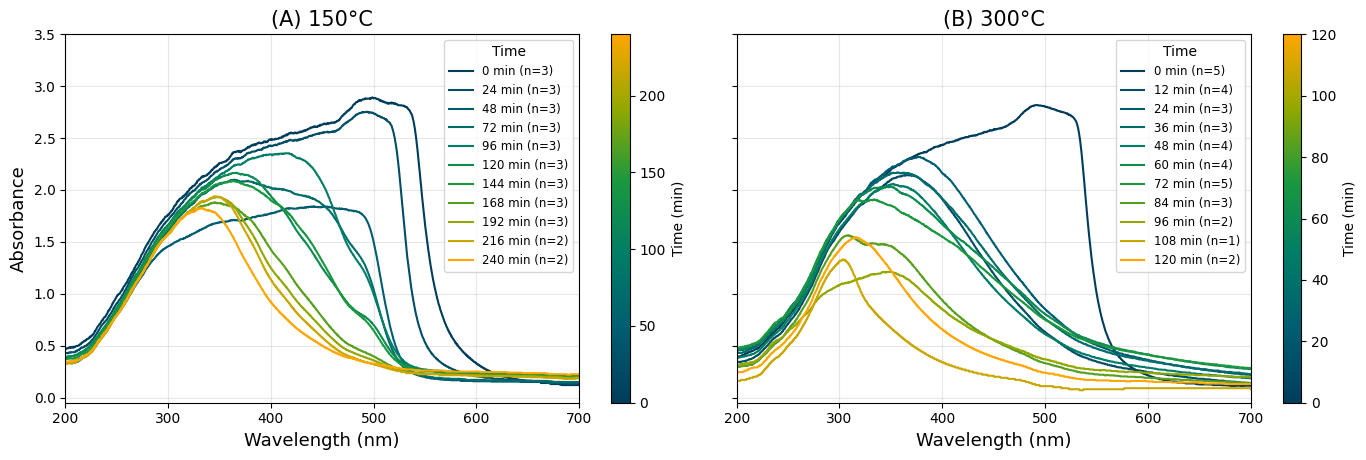

In [46]:
def plot_average(series_dict):
    temps = sorted(series_dict)
    fig, axes = plt.subplots(1, len(temps), figsize=(7 * len(temps), 5),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for i, (ax, temp) in enumerate(zip(axes, temps)):  # ← enumerate 추가
        dates = [d for d in series_dict[temp] if d not in EXCLUDE]

        by_time = {}
        wl_ref = None
        for date in dates:
            for minutes, specs in load_date(date).items():
                for wl, ab in specs:
                    if wl_ref is None:
                        wl_ref = wl
                    elif not np.array_equal(wl, wl_ref):
                        ab = np.interp(wl_ref, wl, ab)
                    by_time.setdefault(minutes, []).append(ab)

        if not by_time:
            ax.set_title(f"{temp} C - no data")
            continue

        times = sorted(by_time)
        norm = mcolors.Normalize(vmin=min(times), vmax=max(times))
        cmap = cmap_palette
        for minutes in times:
            n = len(by_time[minutes])
            ax.plot(wl_ref, np.mean(by_time[minutes], axis=0),
                    color=cmap(norm(minutes)), label=f"{minutes} min (n={n})")

        ax.set_xlim(WL_MIN, WL_MAX)
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.set_xlabel("Wavelength (nm)", fontsize=13)
        
        # ← 내부 루프 제거, 여기서 한 번만 실행
        panel_label = chr(65 + i)  # 'A', 'B', ...
        ax.set_title(f"({panel_label}) {temp}°C", fontsize=15)
        
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8.5, title="Time", loc='upper right')
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label="Time (min)")

    axes[0].set_ylabel("Absorbance", fontsize=13)
    
    
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig("spectra_average.png", dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    (plot_diagnostic if MODE == "diagnostic" else plot_average)(SERIES)